In [1]:
# ===============================================
# 1. INSTALLATION ET SETUP
# ===============================================

# Installation des librairies nécessaires
!pip install duckdb pandas matplotlib seaborn plotly -q

import pandas as pd
import duckdb
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("Setup terminé ! DuckDB est prêt à l'emploi.")
print(f"Version DuckDB : {duckdb.__version__}")
print(f"Version Pandas : {pd.__version__}")

Setup terminé ! DuckDB est prêt à l'emploi.
Version DuckDB : 1.3.0
Version Pandas : 2.2.2


In [2]:
from pathlib import Path
import sys
import pandas as pd

# --- Localiser le project root ---
PROJECT_ROOT = Path.cwd().resolve().parent  # notebooks/ -> parent = project/
RAW_DIR = PROJECT_ROOT / "data" / "raw"

# --- Permet d'importer les modules du back-end (back-end/src/...) ---
BACKEND_SRC = PROJECT_ROOT / "back-end" / "src"
sys.path.append(str(BACKEND_SRC))

# --- Import des helpers identiques à ingestion.py ---
from data_ingestion.ingestion import CsvSource, load_csv 

In [3]:
# Mapping logique : nom_table -> fichier CSV dans data/raw
RAW_FILES = {
    "customers": "olist_customers_dataset.csv",
    "geolocation": "olist_geolocation_dataset.csv",
    "order_items": "olist_order_items_dataset.csv",
    "payments": "olist_order_payments_dataset.csv",
    "reviews": "olist_order_reviews_dataset.csv",
    "orders": "olist_orders_dataset.csv",
    "products": "olist_products_dataset.csv",
    "sellers": "olist_sellers_dataset.csv",
    "prod_translation": "product_category_name_translation.csv",
}

In [4]:
# Chargement local (comme ingestion.py mais depuis un path)
dfs = {}

for name, filename in RAW_FILES.items():
    path = RAW_DIR / filename
    dfs[name] = load_csv(CsvSource(path=path))  # même pattern que ingestion.py
    print(f"✅ {name:<16} {dfs[name].shape}  |  {filename}")


✅ customers        (99441, 5)  |  olist_customers_dataset.csv
✅ geolocation      (1000163, 5)  |  olist_geolocation_dataset.csv
✅ order_items      (112650, 7)  |  olist_order_items_dataset.csv
✅ payments         (103886, 5)  |  olist_order_payments_dataset.csv
✅ reviews          (99224, 7)  |  olist_order_reviews_dataset.csv
✅ orders           (99441, 8)  |  olist_orders_dataset.csv
✅ products         (32951, 9)  |  olist_products_dataset.csv
✅ sellers          (3095, 4)  |  olist_sellers_dataset.csv
✅ prod_translation (71, 2)  |  product_category_name_translation.csv


In [5]:
customers = dfs["customers"]
orders = dfs["orders"]
order_items = dfs["order_items"]
payments = dfs["payments"]
reviews = dfs["reviews"]
products = dfs["products"]
sellers = dfs["sellers"]
geolocation = dfs["geolocation"]
prod_translation = dfs["prod_translation"]

# Sanity checks rapides
display(orders.head())
orders.info()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [8]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

In [9]:
# Sanity check rapide des tables clés
customers = dfs["customers"]
orders = dfs["orders"]
order_items = dfs["order_items"]

print("customers:", customers.shape)
print("orders:", orders.shape)
print("order_items:", order_items.shape)

display(customers.head(2))
display(orders.head(2))
display(order_items.head(2))

customers: (99441, 5)
orders: (99441, 8)
order_items: (112650, 7)


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93


In [10]:
# Vérification des clés de jointure et de leur unicité

print("---- ORDERS / ORDER_ITEMS ----")
print("orders.order_id unique :", orders["order_id"].nunique(), "/", len(orders))
print("order_items.order_id unique :", order_items["order_id"].nunique(), "/", len(order_items))

print("\n---- CUSTOMERS ----")
print("customers.customer_id unique :", customers["customer_id"].nunique(), "/", len(customers))
print("customers.customer_unique_id unique :", customers["customer_unique_id"].nunique())

print("\n---- RELATIONS ----")
print("order_items -> orders (order_id) :",
      order_items["order_id"].isin(orders["order_id"]).mean())

print("orders -> customers (customer_id) :",
      orders["customer_id"].isin(customers["customer_id"]).mean())


---- ORDERS / ORDER_ITEMS ----
orders.order_id unique : 99441 / 99441
order_items.order_id unique : 98666 / 112650

---- CUSTOMERS ----
customers.customer_id unique : 99441 / 99441
customers.customer_unique_id unique : 96096

---- RELATIONS ----
order_items -> orders (order_id) : 1.0
orders -> customers (customer_id) : 1.0


In [14]:
# Dataset analytique : commandes livrées avec détails clients et items
# Base pour les analyses business

df_delivered_orders = (
    orders
    .query("order_status == 'delivered'")
    .merge(customers, on="customer_id", how="inner")
    .merge(order_items, on="order_id", how="inner")
    .assign(
        revenue=lambda d: d["price"].fillna(0) + d["freight_value"].fillna(0)
    )
)

print("df_delivered_orders:", df_delivered_orders.shape)
display(df_delivered_orders.head())

df_delivered_orders: (110197, 19)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,revenue
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,28.62


In [15]:
# KPI business par État (basé sur les commandes livrées)

state_kpi = (
    df_delivered_orders
    .groupby("customer_state", as_index=False)
    .agg(
        nombre_commandes=("order_id", "nunique"),
        nombre_clients=("customer_id", "nunique"),
        chiffre_affaires=("revenue", "sum"),
        panier_moyen=("revenue", "mean"),  # panier moyen au niveau item
    )
    .sort_values("chiffre_affaires", ascending=False)
)

# Arrondi pour lecture
state_kpi["chiffre_affaires"] = state_kpi["chiffre_affaires"].round(2)
state_kpi["panier_moyen"] = state_kpi["panier_moyen"].round(2)

print("state_kpi:", state_kpi.shape)
display(state_kpi.head(10))



state_kpi: (27, 5)


,customer_state,nombre_commandes,nombre_clients,chiffre_affaires,panier_moyen
25,SP,40501,40501,5771713.93,124.26
18,RJ,12350,12350,2055636.12,145.35
10,MG,11354,11354,1819357.56,140.86
22,RS,5345,5345,861734.99,140.48
17,PR,4923,4923,781851.01,138.41
23,SC,3546,3546,595135.45,145.26
4,BA,3256,3256,591137.81,160.50
6,DF,2080,2080,346428.91,147.10
8,GO,1957,1957,334662.57,146.98
7,ES,1995,1995,317701.65,142.79


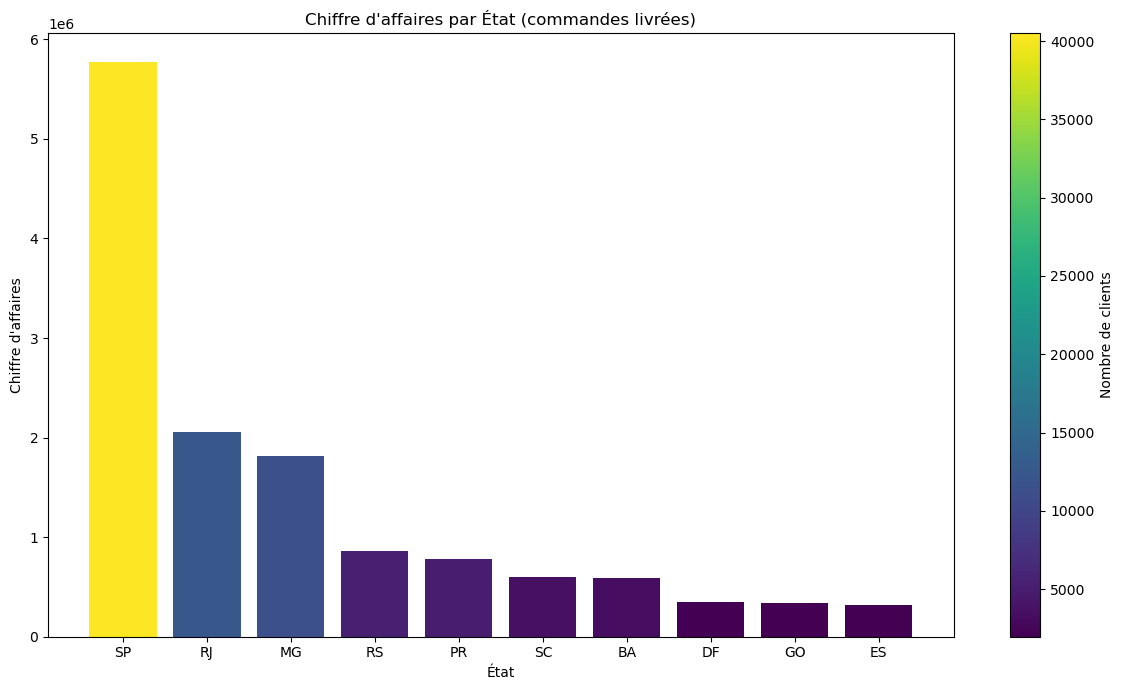

In [16]:
import matplotlib.pyplot as plt
import matplotlib as mpl

top_n = 10
plot_df = state_kpi.head(top_n)

norm = mpl.colors.Normalize(
    vmin=plot_df["nombre_clients"].min(),
    vmax=plot_df["nombre_clients"].max()
)
cmap = mpl.cm.viridis
colors = cmap(norm(plot_df["nombre_clients"]))

fig, ax = plt.subplots(figsize=(12, 7))
ax.bar(plot_df["customer_state"], plot_df["chiffre_affaires"], color=colors)

ax.set_title("Chiffre d'affaires par État (commandes livrées)")
ax.set_xlabel("État")
ax.set_ylabel("Chiffre d'affaires")

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Nombre de clients")

plt.tight_layout()
plt.show()


Le chiffre d’affaires est concentré dans l’État de SP, très au-dessus des autres, ce qui s’explique aussi par son nombre de clients nettement plus élevé. Les États suivants (RJ, MG) forment un second groupe, avec un CA significativement inférieur et une base clients plus réduite.

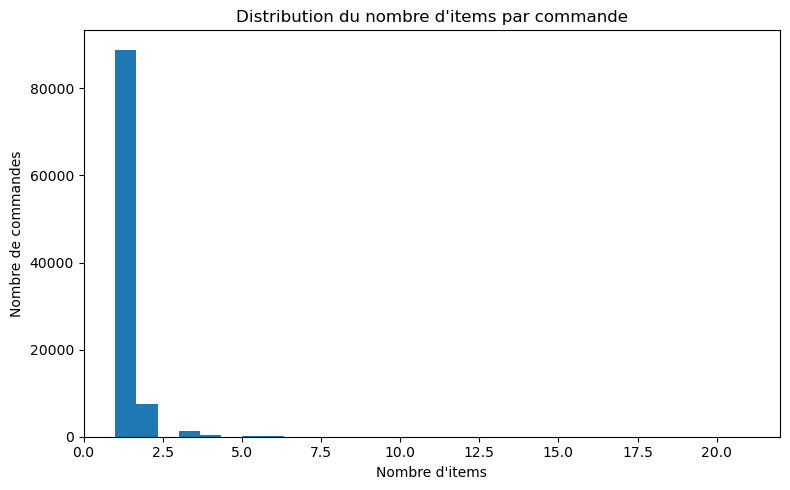

In [17]:
# Nombre d'items par commande (distribution)

fig, ax = plt.subplots(figsize=(8, 5))

df_orders["nombre_items"].plot(
    kind="hist",
    bins=30,
    ax=ax
)

ax.set_title("Distribution du nombre d'items par commande")
ax.set_xlabel("Nombre d'items")
ax.set_ylabel("Nombre de commandes")

plt.tight_layout()
plt.show()


La grande majorité des commandes contient un seul item, avec une décroissance rapide lorsque le nombre d’items augmente. Les commandes multi-items existent mais restent marginales, formant une longue traîne peu fréquente.

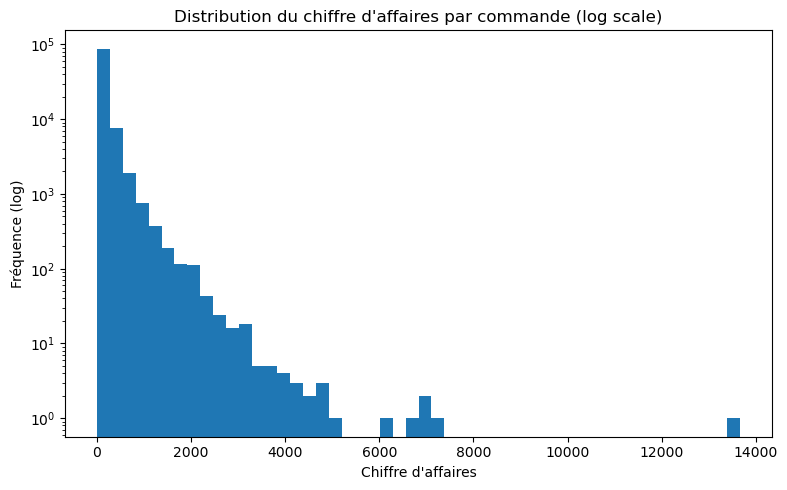

In [18]:
# Long tail du chiffre d'affaires par commande

fig, ax = plt.subplots(figsize=(8, 5))

df_orders["chiffre_affaires"].plot(
    kind="hist",
    bins=50,
    logy=True,
    ax=ax
)

ax.set_title("Distribution du chiffre d'affaires par commande (log scale)")
ax.set_xlabel("Chiffre d'affaires")
ax.set_ylabel("Fréquence (log)")

plt.tight_layout()
plt.show()


La distribution du chiffre d’affaires par commande est asymétrique, avec une majorité de commandes à faible montant et une longue traîne de commandes à valeur élevée. Quelques commandes très coûteuses existent mais restent rares, même à l’échelle logarithmique.

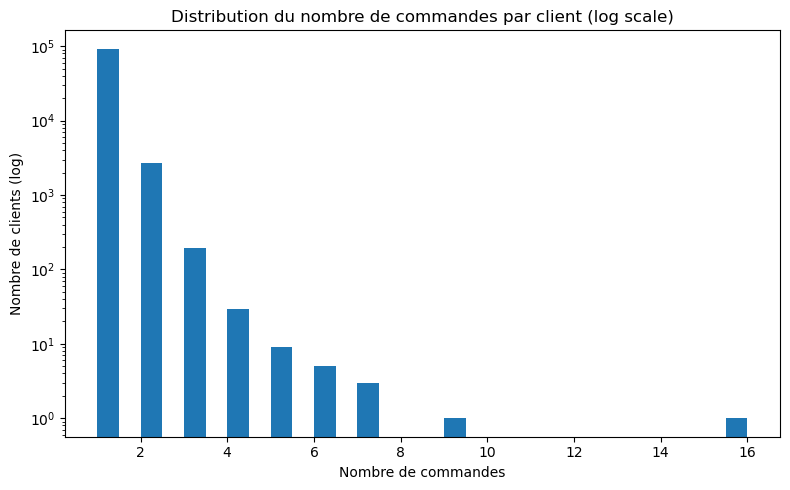

In [19]:
# Nombre de commandes par client réel

orders_per_client = (
    df_orders
    .groupby("customer_unique_id")
    .agg(nombre_commandes=("order_id", "nunique"))
)

fig, ax = plt.subplots(figsize=(8, 5))

orders_per_client["nombre_commandes"].plot(
    kind="hist",
    bins=30,
    logy=True,
    ax=ax
)

ax.set_title("Distribution du nombre de commandes par client (log scale)")
ax.set_xlabel("Nombre de commandes")
ax.set_ylabel("Nombre de clients (log)")

plt.tight_layout()
plt.show()


La majorité des clients passe une seule commande, et le nombre de clients décroît fortement à mesure que le nombre de commandes augmente. Les clients très récurrents existent mais sont rares, formant une longue traîne.

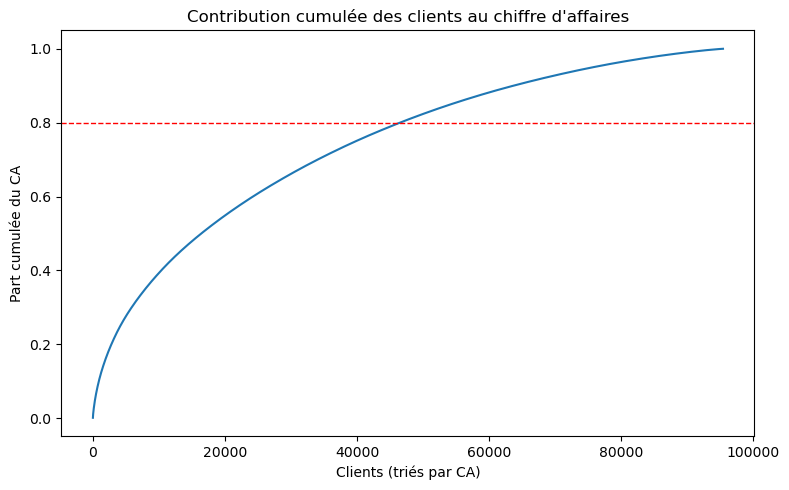

In [20]:
# Contribution cumulée des clients au chiffre d'affaires

client_revenue = (
    df_orders
    .groupby("customer_unique_id")
    .agg(chiffre_affaires=("chiffre_affaires", "sum"))
    .sort_values("chiffre_affaires", ascending=False)
)

client_revenue["cum_share"] = (
    client_revenue["chiffre_affaires"].cumsum()
    / client_revenue["chiffre_affaires"].sum()
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(client_revenue["cum_share"].values)

ax.set_title("Contribution cumulée des clients au chiffre d'affaires")
ax.set_xlabel("Clients (triés par CA)")
ax.set_ylabel("Part cumulée du CA")

ax.axhline(0.8, color="red", linestyle="--", linewidth=1)

plt.tight_layout()
plt.show()


Une fraction relativement réduite de clients génère une part importante du chiffre d’affaires, avec environ 80 % du CA atteint avant l’ensemble des clients. La contribution du CA augmente ensuite plus lentement, indiquant une forte concentration de valeur.

In [21]:
# Vérification de la clé product_id avant merge produits

print(
    "Couverture product_id :",
    order_items["product_id"].isin(dfs["products"]["product_id"]).mean()
)

print(
    "Produits uniques achetés :",
    order_items["product_id"].nunique()
)

print(
    "Produits dans la table products :",
    dfs["products"]["product_id"].nunique()
)

Couverture product_id : 1.0
Produits uniques achetés : 32951
Produits dans la table products : 32951


In [22]:
# Base des interactions pour exploration et feature engineering
# On garde toutes les variables à ce stade

rs_base_full = (
    orders
    .query("order_status == 'delivered'")
    .merge(
        customers,
        on="customer_id",
        how="inner"
    )
    .merge(
        order_items,
        on="order_id",
        how="inner"
    )
    .merge(
        products,
        on="product_id",
        how="inner"
    )
    .merge(
        prod_translation,
        on="product_category_name",
        how="left"
    )
)

print("rs_base_full shape:", rs_base_full.shape)
display(rs_base_full.head())


rs_base_full shape: (110197, 27)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,stationery


In [23]:
# Sélection des variables utiles pour le Recommendation System
# + renommage 
rs_base = (
    rs_base_full
    [
        [
            # Identité & interaction
            "order_id",
            "customer_unique_id",
            "order_purchase_timestamp",
            "product_id",

            # Localisation
            "customer_state",
            "customer_city",

            # Produit
            "product_category_name_english",
            "price",
            "product_photos_qty",
            "product_weight_g",
            "product_length_cm",
            "product_height_cm",
            "product_width_cm",
        ]
    ]
    .rename(
        columns={
            "order_purchase_timestamp": "timestamp",
            "customer_unique_id": "user_id",
            "product_id": "item_id",
            "customer_state": "state",
            "customer_city": "city",
            "product_category_name_english": "category",
            "product_photos_qty": "photos_qty",
            "product_weight_g": "weight_g",
            "product_length_cm": "length_cm",
            "product_height_cm": "height_cm",
            "product_width_cm": "width_cm",
        }
    )
)

print("rs_base shape:", rs_base.shape)
display(rs_base.head())


rs_base shape: (110197, 13)


,order_id,user_id,timestamp,item_id,state,city,category,price,photos_qty,weight_g,length_cm,height_cm,width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,2017-10-02 10:56:33,87285b34884572647811a353c7ac498a,SP,sao paulo,housewares,29.99,4.0,500.0,19.0,8.0,13.0
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,2018-07-24 20:41:37,595fac2a385ac33a80bd5114aec74eb8,BA,barreiras,perfumery,118.70,1.0,400.0,19.0,13.0,19.0
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-08 08:38:49,aa4383b373c6aca5d8797843e5594415,GO,vianopolis,auto,159.90,1.0,420.0,24.0,19.0,21.0
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,2017-11-18 19:28:06,d0b61bfb1de832b15ba9d266ca96e5b0,RN,sao goncalo do amarante,pet_shop,45.00,3.0,450.0,30.0,10.0,20.0
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-13 21:18:39,65266b2da20d04dbe00c5c2d3bb7859e,SP,santo andre,stationery,19.90,4.0,250.0,51.0,15.0,15.0


# Feature engineering

### Feature 1

La popularité d’un produit est mesurée par le nombre de fois où il a été acheté.
Elle capture le fait que les produits fréquemment achetés ont plus de chances d’être pertinents, surtout quand l’historique utilisateur est court.

Formule : populariteˊ(item)=nombre d’achats du produit

In [24]:
# Popularité globale des produits
# Nombre d'achats par produit (baseline du RS)

item_popularity = (
    rs_base
    .groupby("item_id", as_index=False)
    .agg(
        purchase_count=("user_id", "count")
    )
    .sort_values("purchase_count", ascending=False)
)

print("item_popularity shape:", item_popularity.shape)
display(item_popularity.head(10))

item_popularity shape: (32216, 2)


,item_id,purchase_count
21617,aca2eb7d00ea1a7b8ebd4e68314663af,520
8429,422879e10f46682990de24d770e7f83d,484
19290,99a4788cb24856965c36a24e339b6058,477
7206,389d119b48cf3043d311335e499d9c6b,390
6926,368c6c730842d78016ad823897a372db,388
10589,53759a2ecddad2bb87a079a1f1519f73,373
26436,d1c427060a0f73f6b889a5c7c61f2ac4,332
10616,53b36df67ebb7c41585e8d54d6772e08,321
2734,154e7e31ebfa092203795c972e5804a6,274
7881,3dd2a17168ec895c781a9191c1e95ad7,272


### Feature 2

La popularité locale mesure à quelle fréquence un produit est acheté dans une zone donnée.
Elle capte les préférences régionales, utiles pour personnaliser les recommandations selon la localisation de l’utilisateur.

Formule = populariteˊlocal​(item,state)=nombre d’achats du produit dans l’eˊtat

In [25]:
# Popularité des produits par État
# Capte les préférences régionales

item_popularity_state = (
    rs_base
    .groupby(["state", "item_id"], as_index=False)
    .agg(
        purchase_count=("user_id", "count")
    )
    .sort_values(["state", "purchase_count"], ascending=[True, False])
)

print("item_popularity_state shape:", item_popularity_state.shape)
display(item_popularity_state.head(10))


item_popularity_state shape: (59893, 3)


,state,item_id,purchase_count
61,AC,b81a05d0dd312ece2140846909f5ef81,6
13,AC,3a8bbcf3084a3e388588a1b43e188d81,3
18,AC,42fffc68ff7e8176f11baaf4a4227557,2
30,AC,6cc859e89d080218ff4416539ffa030c,2
71,AC,d696750e550fd0f733979dd7e5dff921,2
0,AC,02475368dfb38934fe55f574024fe1d7,1
1,AC,0798196b28c04c8e543322896c882902,1
2,AC,09dbbe2c4f26cad4d560aea043f9632c,1
3,AC,0a41699cb57f40c605d3cfdddd61673b,1
4,AC,108e01163b7588c7924ec8cb5ad81b63,1


### Feature 3

La co-occurrence mesure à quelle fréquence deux produits sont achetés dans la même commande.
Elle capte les relations directes entre produits (produits complémentaires), indépendamment des utilisateurs.

Formule : cooc(i,j)=nombre de commandes contenant i et j

In [26]:
# Co-occurrence produit–produit
# Deux produits sont liés s'ils apparaissent dans la même commande

from itertools import combinations
from collections import Counter

# Produits par commande
items_per_order = (
    rs_base
    .groupby("order_id")["item_id"]
    .apply(list)
)

# Comptage des paires de produits
pair_counter = Counter()

for items in items_per_order:
    # On évite les doublons dans une même commande
    unique_items = sorted(set(items))
    for pair in combinations(unique_items, 2):
        pair_counter[pair] += 1

# Transformation en DataFrame
item_cooccurrence = (
    pd.DataFrame(
        [(i, j, count) for (i, j), count in pair_counter.items()],
        columns=["item_i", "item_j", "cooc_count"]
    )
    .sort_values("cooc_count", ascending=False)
)

print("item_cooccurrence shape:", item_cooccurrence.shape)
display(item_cooccurrence.head(10))

item_cooccurrence shape: (4022, 3)


,item_i,item_j,cooc_count
109,36f60d45225e60c7da4558b070ce4b60,e53e557d5a159f5aa2c5e995dfdf244b,34
722,35afc973633aaeb6b877ff57b2793310,99a4788cb24856965c36a24e339b6058,29
113,4fcb3d9a5f4871e8362dfedbdb02b064,f4f67ccaece962d013a4e1d7dc3a61f7,17
441,36f60d45225e60c7da4558b070ce4b60,3f14d740544f37ece8a9e7bc8349797e,12
230,389d119b48cf3043d311335e499d9c6b,422879e10f46682990de24d770e7f83d,11
66,389d119b48cf3043d311335e499d9c6b,53759a2ecddad2bb87a079a1f1519f73,9
404,368c6c730842d78016ad823897a372db,53759a2ecddad2bb87a079a1f1519f73,8
988,422879e10f46682990de24d770e7f83d,53759a2ecddad2bb87a079a1f1519f73,7
1034,5d790355cbeded0cd60e25cbc4c527a2,5fc3e6a4b52b0c414458104ed4037f1c,6
703,946344697156947d846d27fe0d503033,ad0a798e7941f3a5a2fb8139cb62ad78,6


### Feature 4

La récence mesure à quel point un achat est récent par rapport à une date de référence.
Elle capte le fait que les achats récents sont plus informatifs que les anciens pour recommander des produits pertinents.

Formule : récence=date_référence − timestamp_achat

In [28]:
# Conversion explicite du timestamp en datetime
rs_base["timestamp"] = pd.to_datetime(rs_base["timestamp"])

# Récence des achats
# Plus la valeur est petite, plus l'achat est récent

# Date de référence = dernier achat observé
reference_date = rs_base["timestamp"].max()

rs_base_recency = rs_base.copy()
rs_base_recency["recency_days"] = (
    reference_date - rs_base_recency["timestamp"]
).dt.days

print("Date de référence :", reference_date)
display(
    rs_base_recency[["user_id", "item_id", "timestamp", "recency_days"]].head()
)

Date de référence : 2018-08-29 15:00:37


,user_id,item_id,timestamp,recency_days
0,7c396fd4830fd04220f754e42b4e5bff,87285b34884572647811a353c7ac498a,2017-10-02 10:56:33,331
1,af07308b275d755c9edb36a90c618231,595fac2a385ac33a80bd5114aec74eb8,2018-07-24 20:41:37,35
2,3a653a41f6f9fc3d2a113cf8398680e8,aa4383b373c6aca5d8797843e5594415,2018-08-08 08:38:49,21
3,7c142cf63193a1473d2e66489a9ae977,d0b61bfb1de832b15ba9d266ca96e5b0,2017-11-18 19:28:06,283
4,72632f0f9dd73dfee390c9b22eb56dd6,65266b2da20d04dbe00c5c2d3bb7859e,2018-02-13 21:18:39,196


In [29]:
# Agrégation finale des features pour le modèle de recommandation

rs_model_df = (
    rs_base
    .merge(
        item_popularity,          # popularité globale
        on="item_id",
        how="left"
    )
    .merge(
        item_popularity_state,    # popularité locale (État)
        on=["state", "item_id"],
        how="left",
        suffixes=("", "_state")
    )
)

# Ajout de la récence
reference_date = rs_model_df["timestamp"].max()
rs_model_df["recency_days"] = (
    reference_date - rs_model_df["timestamp"]
).dt.days

print("rs_model_df shape:", rs_model_df.shape)
display(rs_model_df.head())


rs_model_df shape: (110197, 16)


,order_id,user_id,timestamp,item_id,state,city,category,price,photos_qty,weight_g,length_cm,height_cm,width_cm,purchase_count,purchase_count_state,recency_days
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,2017-10-02 10:56:33,87285b34884572647811a353c7ac498a,SP,sao paulo,housewares,29.99,4.0,500.0,19.0,8.0,13.0,4,3,331
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,2018-07-24 20:41:37,595fac2a385ac33a80bd5114aec74eb8,BA,barreiras,perfumery,118.70,1.0,400.0,19.0,13.0,19.0,104,3,35
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-08 08:38:49,aa4383b373c6aca5d8797843e5594415,GO,vianopolis,auto,159.90,1.0,420.0,24.0,19.0,21.0,3,1,21
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,2017-11-18 19:28:06,d0b61bfb1de832b15ba9d266ca96e5b0,RN,sao goncalo do amarante,pet_shop,45.00,3.0,450.0,30.0,10.0,20.0,4,1,283
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-13 21:18:39,65266b2da20d04dbe00c5c2d3bb7859e,SP,santo andre,stationery,19.90,4.0,250.0,51.0,15.0,15.0,40,20,196


In [30]:
# Dictionnaire rapide des co-occurrences
cooc_dict = {
    (row.item_i, row.item_j): row.cooc_count
    for row in item_cooccurrence.itertuples(index=False)
}

def compute_cooc_score(item, basket):
    """Somme des co-occurrences entre un item et les autres items du panier"""
    score = 0
    for other in basket:
        if item == other:
            continue
        score += cooc_dict.get((item, other), 0)
        score += cooc_dict.get((other, item), 0)
    return score


# Calcul du score par (order_id, item_id)
cooc_score_df = []

items_per_order = (
    rs_base
    .groupby("order_id")["item_id"]
    .apply(list)
)

for order_id, items in items_per_order.items():
    unique_items = list(set(items))
    for item in unique_items:
        cooc_score_df.append(
            {
                "order_id": order_id,
                "item_id": item,
                "cooc_score": compute_cooc_score(item, unique_items),
            }
        )

cooc_score_df = pd.DataFrame(cooc_score_df)

print("cooc_score_df shape:", cooc_score_df.shape)
display(cooc_score_df.head())


cooc_score_df shape: (100196, 3)


,order_id,item_id,cooc_score
0,00010242fe8c5a6d1ba2dd792cb16214,4244733e06e7ecb4970a6e2683c13e61,0
1,00018f77f2f0320c557190d7a144bdd3,e5f2d52b802189ee658865ca93d83a8f,0
2,000229ec398224ef6ca0657da4fc703e,c777355d18b72b67abbeef9df44fd0fd,0
3,00024acbcdf0a6daa1e931b038114c75,7634da152a4610f1595efa32f14722fc,0
4,00042b26cf59d7ce69dfabb4e55b4fd9,ac6c3623068f30de03045865e4e10089,0


In [31]:
# ===============================
# Table finale du modèle RS
# ===============================

rs_model_df = (
    rs_base
    # Popularité globale
    .merge(
        item_popularity,
        on="item_id",
        how="left"
    )
    # Popularité locale (État)
    .merge(
        item_popularity_state,
        on=["state", "item_id"],
        how="left",
        suffixes=("", "_state")
    )
    # Co-occurrence agrégée
    .merge(
        cooc_score_df,
        on=["order_id", "item_id"],
        how="left"
    )
)

# Ajout de la récence
reference_date = rs_model_df["timestamp"].max()
rs_model_df["recency_days"] = (
    reference_date - rs_model_df["timestamp"]
).dt.days

print("rs_model_df shape:", rs_model_df.shape)

print("\nColonnes présentes :")
for col in rs_model_df.columns:
    print("-", col)

display(rs_model_df.head())


rs_model_df shape: (110197, 17)

Colonnes présentes :
- order_id
- user_id
- timestamp
- item_id
- state
- city
- category
- price
- photos_qty
- weight_g
- length_cm
- height_cm
- width_cm
- purchase_count
- purchase_count_state
- cooc_score
- recency_days


,order_id,user_id,timestamp,item_id,state,city,category,price,photos_qty,weight_g,length_cm,height_cm,width_cm,purchase_count,purchase_count_state,cooc_score,recency_days
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,2017-10-02 10:56:33,87285b34884572647811a353c7ac498a,SP,sao paulo,housewares,29.99,4.0,500.0,19.0,8.0,13.0,4,3,0,331
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,2018-07-24 20:41:37,595fac2a385ac33a80bd5114aec74eb8,BA,barreiras,perfumery,118.70,1.0,400.0,19.0,13.0,19.0,104,3,0,35
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-08 08:38:49,aa4383b373c6aca5d8797843e5594415,GO,vianopolis,auto,159.90,1.0,420.0,24.0,19.0,21.0,3,1,0,21
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,2017-11-18 19:28:06,d0b61bfb1de832b15ba9d266ca96e5b0,RN,sao goncalo do amarante,pet_shop,45.00,3.0,450.0,30.0,10.0,20.0,4,1,0,283
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-13 21:18:39,65266b2da20d04dbe00c5c2d3bb7859e,SP,santo andre,stationery,19.90,4.0,250.0,51.0,15.0,15.0,40,20,0,196


La table rs_model_df contient une ligne par interaction utilisateur–produit, enrichie par des features de popularité globale et locale, de co-occurrence et de temporalité, ainsi que par des caractéristiques produit et contextuelles.

## Analyse données manquantes

In [32]:
rs_model_df.isna().mean().sort_values(ascending=False)

category                0.014147
photos_qty              0.013948
weight_g                0.000163
width_cm                0.000163
height_cm               0.000163
length_cm               0.000163
cooc_score              0.000000
purchase_count_state    0.000000
purchase_count          0.000000
order_id                0.000000
user_id                 0.000000
price                   0.000000
city                    0.000000
state                   0.000000
item_id                 0.000000
timestamp               0.000000
recency_days            0.000000
dtype: float64

Les valeurs manquantes sont faibles et concentrées sur category et photos_qty (≈ 1–1,5 %), ainsi que marginalement sur les dimensions produit. Aucune feature clé du système de recommandation (popularité, récence, co-occurrence) n’est affectée.

In [35]:
# Vérifie si la chaîne "missing" existe déjà (valeur réelle)
has_missing_token = (rs_model_df["category"] == "missing").any()

# Compte exact des NaN
n_nan_category = rs_model_df["category"].isna().sum()

print("category contient déjà la valeur 'missing' ?", has_missing_token)
print("Nombre de NaN dans category :", n_nan_category)

# Montre quelques lignes où category est NaN (preuve visuelle)
display(rs_model_df.loc[rs_model_df["category"].isna(), ["item_id", "category"]].head(10))

category contient déjà la valeur 'missing' ? False
Nombre de NaN dans category : 1559


,item_id,category
119,71225f49be70df4297892f6a5fa62171,NaN
206,9820e04e332fc450d6fd975befc1bc28,NaN
258,3bc5164bc7f4be77002d6651da65c98c,NaN
296,5a848e4ab52fd5445cdc07aab1c40e48,NaN
365,c600d7f13104e8db2ca2b9fa78581409,NaN
513,de6702c748c719cbd13bb814f006ba22,NaN
570,26a4f62a409a78816adb31e0d729a163,NaN
755,5a848e4ab52fd5445cdc07aab1c40e48,NaN
784,0ae10ca52e6cb8745e17c11e7c43907c,NaN
1020,1954739d84629e7323a4295812a3e0ec,NaN


In [36]:
num_features = ["photos_qty", "weight_g", "length_cm", "height_cm", "width_cm"]

# Nombre de NaN par variable
print("NaN par variable :")
display(rs_model_df[num_features].isna().sum())

# Vérification des zéros (parfois 0 = manquant codé)
print("\nZéros par variable :")
display((rs_model_df[num_features] == 0).sum())

# Aperçu des lignes qui ont au moins un NaN numérique
display(rs_model_df.loc[rs_model_df[num_features].isna().any(axis=1), num_features].head(10))

NaN par variable :


photos_qty    1537
weight_g        18
length_cm       18
height_cm       18
width_cm        18
dtype: int64


Zéros par variable :


photos_qty    0
weight_g      8
length_cm     0
height_cm     0
width_cm      0
dtype: int64

,photos_qty,weight_g,length_cm,height_cm,width_cm
119,NaN,200.0,16.0,2.0,11.0
206,NaN,10800.0,40.0,40.0,30.0
258,NaN,550.0,16.0,11.0,19.0
296,NaN,400.0,20.0,12.0,15.0
365,NaN,2400.0,42.0,15.0,27.0
513,NaN,150.0,16.0,9.0,11.0
570,NaN,11100.0,62.0,33.0,25.0
755,NaN,400.0,20.0,12.0,15.0
784,NaN,700.0,30.0,30.0,30.0
1085,NaN,1150.0,40.0,11.0,15.0


In [37]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score

In [40]:
# Variables numériques (scalées) : intensité / contexte de l'interaction
num_features = [
    "price",
    "photos_qty",
    "weight_g",
    "length_cm",
    "height_cm",
    "width_cm",
    "purchase_count",
    "purchase_count_state",
    "cooc_score",
    "recency_days",
]

# Variables catégorielles (one-hot) : contexte discret
cat_features = [
    "state",
    "city",
    "category",
]

### Construire le dataset “positifs” (achats observés)

In [ ]:
# On garde les colonnes nécessaires au modèle
base_cols = ["user_id", "item_id"] + num_features + cat_features

# Positifs = interactions observées (achat)
positives = rs_model_df[base_cols].copy()
positives["label"] = 1  # y=1 : l'utilisateur a acheté l'item
print("positives:", positives.shape)
positives.head()

### Générer des “négatifs” par sampling (produits non achetés)

Pour chaque utilisateur, on choisit quelques items qu’il n’a pas achetés → label=0.
Un négatif par positif (ratio=1). On pourra augmenter après.

In [45]:
# Paramètre : ratio négatifs / positifs (1 = même nombre)
neg_ratio = 1
rng = np.random.default_rng(42)

all_items = rs_model_df["item_id"].unique()

# Historique d'achats par user (pour exclure les items déjà achetés)
user_bought = (
    rs_model_df.groupby("user_id")["item_id"]
    .apply(set)
    .to_dict()
)

neg_rows = []

# On échantillonne des utilisateurs à partir des positives
sampled_users = positives["user_id"].values
sampled_n = len(positives) * neg_ratio

# On tire des users au hasard, puis un item non acheté
for _ in range(sampled_n):
    u = sampled_users[rng.integers(0, len(sampled_users))]
    bought = user_bought[u]

    # Tirage jusqu'à trouver un item non acheté 
    while True:
        it = all_items[rng.integers(0, len(all_items))]
        if it not in bought:
            break

    neg_rows.append((u, it))

negatives_key = pd.DataFrame(neg_rows, columns=["user_id", "item_id"])

# Pour construire les features des négatifs, on rejoint avec les features item (et contexte user via state/city)
# On prend une version "item metadata" en dédoublonnant item_id
item_meta = (
    rs_model_df[["item_id"] + ["category"] + ["price", "photos_qty", "weight_g", "length_cm", "height_cm", "width_cm", "purchase_count"]]
    .drop_duplicates("item_id")
)

# Pour le contexte user (state/city), on prend la modalité la plus fréquente par user (simple et stable)
user_meta = (
    rs_model_df.groupby("user_id")[["state", "city"]]
    .agg(lambda s: s.mode().iloc[0] if not s.mode().empty else s.iloc[0])
    .reset_index()
)

# Features locales/temps/cooc : pour les négatifs, on met cooc_score=0 (pas dans un panier) et recency = médiane (neutre)
# purchase_count_state dépend de (state,item), on la rejoint plus bas
negatives = (
    negatives_key
    .merge(user_meta, on="user_id", how="left")
    .merge(item_meta, on="item_id", how="left")
)

# Popularité locale item par state
negatives = negatives.merge(
    item_popularity_state.rename(columns={"purchase_count": "purchase_count_state"}),
    on=["state", "item_id"],
    how="left"
)

# Valeurs neutres pour une non-interaction
negatives["cooc_score"] = 0
negatives["recency_days"] = rs_model_df["recency_days"].median()

# Label négatif
negatives["label"] = 0

# Harmoniser les colonnes avec positives
negatives = negatives[base_cols + ["label"]]

print("negatives:", negatives.shape)
negatives.head()


negatives: (110197, 16)


,user_id,item_id,price,photos_qty,weight_g,length_cm,height_cm,width_cm,purchase_count,purchase_count_state,cooc_score,recency_days,state,city,category,label
0,2a0c45027573d5a539ccf698c30d1f2c,4db04f1ae830079ac83e0fc9c63216a3,150.00,1.0,167.0,21.0,13.0,16.0,2,NaN,0,220.0,MG,belo horizonte,watches_gifts,0
1,50658d1d512126b98a482b1bee95c888,cb43fd7a1263540b74b5212d93ad11a3,599.65,2.0,700.0,30.0,16.0,16.0,1,NaN,0,220.0,PA,maraba,health_beauty,0
2,544f499e8d7423126aca77fecdb2b254,55a1e3d39ace9c0b217f6c30b04d43c0,89.90,2.0,550.0,45.0,15.0,35.0,2,2.0,0,220.0,SP,santos,luggage_accessories,0
3,548315a289f7a389b9a7ff373e13004c,3116933c5301f90d4446f1ac5912edae,282.00,1.0,2800.0,22.0,19.0,22.0,1,NaN,0,220.0,SP,sao paulo,construction_tools_construction,0
4,9cfb33b777e28002bb1cca34f17124dc,11250b0d4b709fee92441c5f34122aed,412.00,2.0,3000.0,30.0,30.0,20.0,22,11.0,0,220.0,SP,santo andre,agro_industry_and_commerce,0


### Dataset final + split train/test

In [42]:
# Dataset final (positifs + négatifs)
df_train = pd.concat([positives, negatives], axis=0, ignore_index=True)

# Mélange aléatoire
df_train = df_train.sample(frac=1, random_state=42).reset_index(drop=True)

X = df_train[base_cols]
y = df_train["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)
y.value_counts(normalize=True)

Train: (176315, 15) Test: (44079, 15)


label
1    0.5
0    0.5
Name: proportion, dtype: float64

### Pipeline preprocessing (num + cat) + Logistic Regression

In [43]:
# Pipeline numérique :
# - impute médiane pour gérer les NaN
# - standardise pour que la logreg apprenne correctement (mêmes échelles)
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

# Pipeline catégoriel :
# - remplace NaN par "missing" (modalité explicite)
# - one-hot encoding robuste (ignore catégories inconnues)
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

# ColumnTransformer : applique num aux colonnes num_features et cat aux colonnes cat_features
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features),
    ]
)

# Modèle de scoring :
# LogisticRegression produit une probabilité P(label=1 | features)
# class_weight="balanced" si classes déséquilibrées (ici c'est inutile car on a contrôlé le ratio)
clf = LogisticRegression(
    max_iter=1000,
    n_jobs=None
)

# Pipeline : preprocessing + modèle
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("clf", clf),
    ]
)

model


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['price', 'photos_qty',
                                                   'weight_g', 'length_cm',
                                                   'height_cm', 'width_cm',
                                                   'purchase_count',
                                                   'purchase_count_state',
                                                   'cooc_score',
                                                   'recency_days']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['state', 'city',
                                                   'category'])])),
                ('clf', LogisticRegression(max_iter=1000))])

### Entraînement + évaluation (AUC / Average Precision)

In [44]:
# Entraîner le pipeline
model.fit(X_train, y_train)

# Score probabiliste (pour ranking)
y_proba = model.predict_proba(X_test)[:, 1]

# Métriques adaptées à scoring binaire / ranking
auc = roc_auc_score(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)

print(f"ROC-AUC: {auc:.3f}")
print(f"Average Precision (PR-AUC): {ap:.3f}")


ROC-AUC: 0.792
Average Precision (PR-AUC): 0.833


### Fonction simple “recommander top-N pour un user”

In [46]:
def recommend_top_n(model, user_id, candidates_df, n=10):
    """
    Retourne les Top-N items recommandés pour un user_id.
    candidates_df doit contenir les colonnes base_cols (features prêtes).
    """
    user_rows = candidates_df[candidates_df["user_id"] == user_id].copy()
    if user_rows.empty:
        return pd.DataFrame()

    X_cand = user_rows[base_cols]
    user_rows["score"] = model.predict_proba(X_cand)[:, 1]

    return user_rows.sort_values("score", ascending=False).head(n)[
        ["user_id", "item_id", "category", "state", "city", "score"]
    ]

### Visualisation de la performance en fonction de C

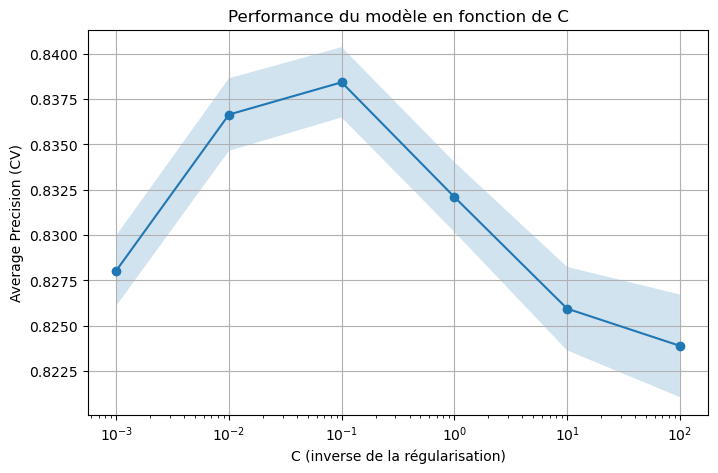

,C,mean_AP,std_AP
0,0.001,0.828037,0.001944
1,0.010,0.836650,0.002002
2,0.100,0.838430,0.001940
3,1.000,0.832101,0.001925
4,10.000,0.825943,0.002303
5,100.000,0.823893,0.002831


In [47]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np
import matplotlib.pyplot as plt

# Valeurs de C à tester (large au départ, échelle logarithmique)
C_values = np.logspace(-3, 2, 6)  # [0.001, 0.01, 0.1, 1, 10, 100]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

mean_ap_scores = []
std_ap_scores = []

for C in C_values:
    # Modèle Ridge Logistic pour une valeur donnée de C
    clf = LogisticRegression(
        penalty="l2",
        C=C,
        max_iter=1000,
        solver="lbfgs"
    )

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("clf", clf),
        ]
    )

    # Validation croisée sur Average Precision (adaptée au ranking)
    cv_scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring="average_precision",
        n_jobs=-1
    )

    mean_ap_scores.append(cv_scores.mean())
    std_ap_scores.append(cv_scores.std())

# Visualisation
plt.figure(figsize=(8, 5))
plt.semilogx(C_values, mean_ap_scores, marker="o")
plt.fill_between(
    C_values,
    np.array(mean_ap_scores) - np.array(std_ap_scores),
    np.array(mean_ap_scores) + np.array(std_ap_scores),
    alpha=0.2
)
plt.xlabel("C (inverse de la régularisation)")
plt.ylabel("Average Precision (CV)")
plt.title("Performance du modèle en fonction de C")
plt.grid(True)
plt.show()

# Tableau récapitulatif
pd.DataFrame({
    "C": C_values,
    "mean_AP": mean_ap_scores,
    "std_AP": std_ap_scores
})

- La performance augmente fortement de C = 0.001 à C = 0.1

- Le maximum est atteint autour de C ≈ 0.1

Au-delà (C ≥ 1), la performance baisse de façon monotone → début de sur-apprentissage

Zone intéressante est donc : [0.03 ; 0.3], éventuellement un peu autour.

### Zoom fin autour du bon intervalle

On est passé de :

- cross_val_score → exploration grossière

- à cross_validate → exploration fine + stats

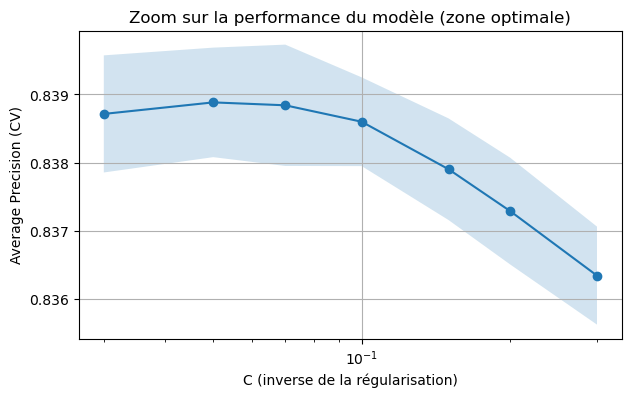

In [50]:
from sklearn.model_selection import cross_validate
# Zoom plus fin autour de la zone optimale
C_fine = [0.03, 0.05, 0.07, 0.1, 0.15, 0.2, 0.3]

mean_ap_fine = []
std_ap_fine = []

for C in C_fine:
    pipeline.set_params(clf__C=C)
    
    cv_scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        scoring="average_precision",
        cv=5,
        n_jobs=-1
    )
    
    mean_ap_fine.append(cv_scores["test_score"].mean())
    std_ap_fine.append(cv_scores["test_score"].std())
plt.figure(figsize=(7, 4))
plt.semilogx(C_fine, mean_ap_fine, marker="o")
plt.fill_between(
    C_fine,
    np.array(mean_ap_fine) - np.array(std_ap_fine),
    np.array(mean_ap_fine) + np.array(std_ap_fine),
    alpha=0.2
)
plt.xlabel("C (inverse de la régularisation)")
plt.ylabel("Average Precision (CV)")
plt.title("Zoom sur la performance du modèle (zone optimale)")
plt.grid(True)
plt.show()

In [51]:
pd.DataFrame({
    "C": C_fine,
    "mean_AP": mean_ap_fine,
    "std_AP": std_ap_fine
})

,C,mean_AP,std_AP
0,0.03,0.838715,0.000858
1,0.05,0.838884,0.000802
2,0.07,0.838841,0.000889
3,0.10,0.838600,0.000650
4,0.15,0.837905,0.000744
5,0.20,0.837292,0.000782
6,0.30,0.836346,0.000718
